In [1]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_680fc3608109f33674d98c2587c17c23"

---
### Leer dataset con datos de partidos internacionales de 1827 a 2020

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/results.csv")

In [3]:
print(df.shape)
print(df.dtypes)
df.head(5)

(49363, 9)
date           object
home_team      object
away_team      object
home_score    float64
away_score    float64
tournament     object
city           object
country        object
neutral          bool
dtype: object


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [4]:
df[df["home_score"].notna()].tail(10)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49281,2026-05-31,United States,Senegal,3.0,2.0,Friendly,Charlotte,United States,False
49282,2026-05-31,Japan,Iceland,1.0,0.0,Friendly,Tokyo,Japan,False
49283,2026-06-01,Austria,Tunisia,1.0,0.0,Friendly,Vienna,Austria,False
49284,2026-06-01,Bulgaria,Montenegro,0.0,1.0,Friendly,Plovdiv,Bulgaria,False
49285,2026-06-01,Canada,Uzbekistan,2.0,0.0,Friendly,Edmonton,Canada,False
49286,2026-06-01,Colombia,Costa Rica,3.0,1.0,Friendly,Bogota,Colombia,False
49287,2026-06-01,Norway,Sweden,3.0,1.0,Friendly,Oslo,Norway,False
49288,2026-06-01,Slovakia,Malta,2.0,1.0,Friendly,Dunajská Streda,Slovakia,False
49289,2026-06-01,Turkey,North Macedonia,4.0,0.0,Friendly,Istanbul,Turkey,False
49290,2026-06-01,Maldives,Afghanistan,0.0,1.0,Diamond Jubilee International Football Tournament,Malé,Maldives,False


## Mostrar que competiciones están disponibles en el dataset

In [5]:
# Top tournaments by match count
print(df['tournament'].value_counts().head(30))

tournament
Friendly                                18286
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
Gulf Cup                                  410
Island Games                              394
UEFA Euro                                 388
Asian Games                               368
COSAFA Cup                                354
AFF Championship       

---
### Definir weights (importancia) para la recencia y torneo de cada partido

In [6]:
# Competition weights
competition_weights = {
    # Tier 1: World Cup
    'FIFA World Cup': 1.0,
    
    # Tier 2: Major continental tournaments
    'UEFA Euro': 0.9,
    'Copa América': 0.9,
    'AFC Asian Cup': 0.9,
    'Gold Cup': 0.9,
    'African Cup of Nations': 0.9,
    
    # Tier 3: Qualifying & Nations Leagues
    'FIFA World Cup qualification': 0.7,
    'UEFA Euro qualification': 0.7,
    'CONCACAF Nations League': 0.7,
    'UEFA Nations League': 0.7,
    'African Cup of Nations qualification': 0.7,
    'AFC Asian Cup qualification': 0.7,
    
    # Tier 4: Regional tournaments
    'Gulf Cup': 0.5,
    'Arab Cup': 0.5,
    'AFF Championship': 0.5,
    'CFU Caribbean Cup': 0.5,
    
    # Tier 5: Friendlies
    'Friendly': 0.3,
}

# Drop everything not in the dict
df_clean = df[df['tournament'].isin(competition_weights.keys())].copy()

# Map competition weight
df_clean['competition_weight'] = df_clean['tournament'].map(competition_weights)

# Parse date and compute recency weight
df_clean['date'] = pd.to_datetime(df_clean['date'])
reference_date = df_clean['date'].max()
df_clean['years_ago'] = (reference_date - df_clean['date']).dt.days / 365.25

# lambda = 0.2 (just to try something)
lam = 0.2
df_clean['recency_weight'] = np.exp(-lam * df_clean['years_ago'])

# Final weight
df_clean['weight'] = df_clean['competition_weight'] * df_clean['recency_weight']

# Sanity check
print(f"Rows before filtering: {len(df)}")
print(f"Rows after filtering:  {len(df_clean)}")
print(f"\nDate range: {df_clean['date'].min().date()} → {df_clean['date'].max().date()}")
print(f"\nWeight stats:")
print(df_clean['weight'].describe().round(4))

Rows before filtering: 49363
Rows after filtering:  39223

Date range: 1872-11-30 → 2026-06-27

Weight stats:
count    39223.0000
mean         0.0653
std          0.1379
min          0.0000
25%          0.0001
50%          0.0039
75%          0.0488
max          1.0000
Name: weight, dtype: float64


## Decidir un año de "cutoff" (partidos muy viejos son inútiles), y reducir dataset a solo partidos donde participa alguno de los equipos que están en el mundial

In [7]:
# See how data distributes across eras
cutoffs = [1970, 1980, 1990, 2000, 2005, 2010]
for year in cutoffs:
    n = len(df_clean[df_clean['date'].dt.year >= year])
    print(f"From {year}: {n} rows")

From 1970: 33528 rows
From 1980: 30718 rows
From 1990: 26953 rows
From 2000: 21496 rows
From 2005: 17409 rows
From 2010: 13626 rows


In [8]:
# Check match counts per confederation after 2000 cutoff
# First let's see which teams have the fewest matches
df_2000 = df_clean[df_clean['date'].dt.year >= 2000].copy()

# Count appearances per team (home + away)
home_counts = df_2000['home_team'].value_counts()
away_counts = df_2000['away_team'].value_counts()
total_counts = (home_counts.add(away_counts, fill_value=0)).sort_values()

print("Teams with fewest matches (bottom 20):")
print(total_counts.head(20))
print(f"\nTotal unique teams: {total_counts.shape[0]}")
print(f"Teams with fewer than 10 matches: {(total_counts < 10).sum()}")
print(f"Teams with fewer than 20 matches: {(total_counts < 20).sum()}")

Teams with fewest matches (bottom 20):
Åland Islands              1.0
Tamil Eelam                1.0
Székely Land               1.0
Ticino                     1.0
Surrey                     1.0
Silesia                    1.0
Seborga                    1.0
Sápmi                      1.0
Cascadia                   1.0
Ryūkyū                     1.0
East Turkestan             1.0
Elba Island                1.0
Cilento                    1.0
Parishes of Jersey         1.0
Saugeais                   1.0
Saint Helena               1.0
United Koreans in Japan    1.0
Ynys Môn                   1.0
Gozo                       1.0
Madrid                     1.0
Name: count, dtype: float64

Total unique teams: 281
Teams with fewer than 10 matches: 57
Teams with fewer than 20 matches: 63


In [9]:
# Get teams in 2026 world cup
teams_2026 = [
    # CONMEBOL
    'Argentina', 'Brazil', 'Uruguay', 'Colombia', 'Ecuador', 'Paraguay',
    # UEFA
    'Germany', 'Spain', 'France', 'England', 'Portugal', 'Netherlands', 'Belgium', 'Croatia', 'Austria', 
    'Switzerland', 'Bosnia and Herzegovina', 'Czech Republic', 'Norway', 'Scotland', 'Sweden', 'Turkey',
    # CONCACAF, '
    'United States', 'Mexico', 'Canada', 'Panama', 'Curaçao', 'Haiti',
    # CAF
    'Morocco', 'Senegal', 'Egypt', 'Cape Verde', 'South Africa', 'DR Congo', 'Ghana', 'Tunisia', 'Algeria',
    'Ivory Coast',
    # AFC
    'Australia', 'Iran', 'Iraq', 'Japan', 'Jordan', 'Qatar', 'Saudi Arabia', 'South Korea', 'Uzbekistan',
    # OFC
    'New Zealand',
]

teams_in_dataset = set(df_clean['home_team'].unique()) | set(df_clean['away_team'].unique())

matched = [t for t in teams_2026 if t in teams_in_dataset]
unmatched = [t for t in teams_2026 if t not in teams_in_dataset]

print(f"Matched: {len(matched)}/{len(teams_2026)}")
print(f"\nUnmatched teams:")
print(unmatched)

Matched: 48/48

Unmatched teams:
[]


In [10]:
# Apply year cutoff
df_clean = df_clean[df_clean['date'].dt.year >= 1998].copy()

valid_teams = set(teams_2026)

# Keep matches where at least one team is a 2026 WC participant
df_clean = df_clean[
    df_clean['home_team'].isin(teams_2026) | 
    df_clean['away_team'].isin(teams_2026)
].copy()

# Recompute years_ago and weights
reference_date = df_clean.loc[df_clean['home_score'].notna(), 'date'].max()
df_clean['years_ago'] = (reference_date - df_clean['date']).dt.days / 365.25
df_clean['recency_weight'] = np.exp(-lam * df_clean['years_ago'])
df_clean['weight'] = df_clean['competition_weight'] * df_clean['recency_weight']

# Zero out future matches
df_clean.loc[df_clean['date'] > reference_date,
             ['recency_weight', 'weight']] = 0

print(f"Final rows: {len(df_clean)}")
print(f"Unique teams: {len(set(df_clean['home_team'].unique()) | set(df_clean['away_team'].unique()))}")
print(f"\nWeight stats:")
print(df_clean['weight'].describe().round(4))
print(f"\nSample of recent high-weight matches:")
df_clean.nlargest(5, 'weight')[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'weight']]

Final rows: 12026
Unique teams: 220

Weight stats:
count    12026.0000
mean         0.1083
std          0.1616
min          0.0000
25%          0.0075
50%          0.0292
75%          0.1353
max          0.8363
Name: weight, dtype: float64

Sample of recent high-weight matches:


,date,home_team,away_team,home_score,away_score,tournament,weight
49107,2026-01-18,Morocco,Senegal,3.0,0.0,African Cup of Nations,0.836328
49106,2026-01-17,Egypt,Nigeria,0.0,0.0,African Cup of Nations,0.835870
49104,2026-01-14,Senegal,Egypt,1.0,0.0,African Cup of Nations,0.834498
49105,2026-01-14,Morocco,Nigeria,0.0,0.0,African Cup of Nations,0.834498
49102,2026-01-10,Algeria,Nigeria,0.0,2.0,African Cup of Nations,0.832672


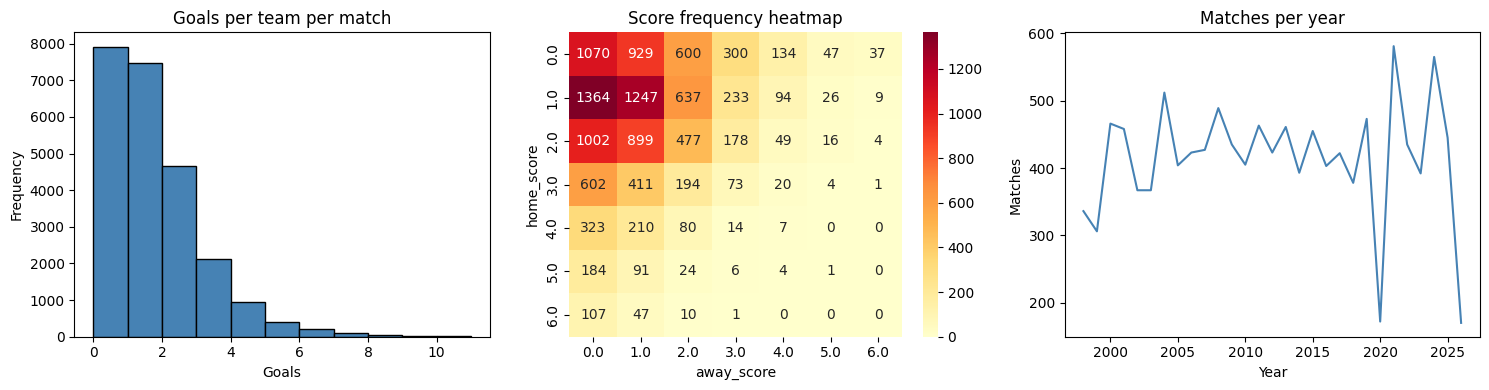

Home wins: 47.5%
Draws:     23.9%
Away wins: 27.9%
Avg goals per match: 2.66


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Goal distribution
all_goals = pd.concat([df_clean['home_score'], df_clean['away_score']])
axes[0].hist(all_goals.dropna(), bins=range(0, 12), edgecolor='black', color='steelblue')
axes[0].set_title('Goals per team per match')
axes[0].set_xlabel('Goals')
axes[0].set_ylabel('Frequency')

# Score distribution heatmap (top scores only)
score_counts = df_clean.groupby(['home_score', 'away_score']).size().reset_index(name='count')
score_pivot = score_counts[
    (score_counts['home_score'] <= 6) & 
    (score_counts['away_score'] <= 6)
].pivot(index='home_score', columns='away_score', values='count').fillna(0)
sns.heatmap(score_pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Score frequency heatmap')

# Matches per year
df_clean['year'] = df_clean['date'].dt.year
df_clean.groupby('year').size().plot(ax=axes[2], color='steelblue')
axes[2].set_title('Matches per year')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Matches')

plt.tight_layout()
plt.show()

# Key stats
total = len(df_clean)
home_wins = (df_clean['home_score'] > df_clean['away_score']).sum()
draws = (df_clean['home_score'] == df_clean['away_score']).sum()
away_wins = (df_clean['home_score'] < df_clean['away_score']).sum()
print(f"Home wins: {home_wins/total:.1%}")
print(f"Draws:     {draws/total:.1%}")
print(f"Away wins: {away_wins/total:.1%}")
print(f"Avg goals per match: {(df_clean['home_score'] + df_clean['away_score']).mean():.2f}")

---
### Inicialización de parámetros y función de corrección para Dixon-Coles

In [12]:
from scipy.optimize import minimize
from scipy.stats import poisson

# --- Piece 1: Parameter Initialization ---

# Get all unique teams
all_teams = sorted(set(df_clean['home_team'].unique()) | set(df_clean['away_team'].unique()))
n_teams = len(all_teams)

# Create a mapping from team name to index
team_index = {team: i for i, team in enumerate(all_teams)}

print(f"Total teams to fit: {n_teams}")

def initialize_params(n_teams):
    """
    Initial parameter vector layout:
    [attack_0, attack_1, ..., attack_n,   <- n_teams values
     defense_0, defense_1, ..., defense_n, <- n_teams values
     home_advantage,                        <- 1 value
     rho]                                   <- 1 value
    Total length: 2 * n_teams + 2
    """
    attack_params = np.zeros(n_teams)       # log scale, 0 = average
    defense_params = np.zeros(n_teams)      # log scale, 0 = average
    home_advantage = np.array([0.25])       # small positive boost
    rho = np.array([-0.1])                  # small negative, typical starting value
    
    return np.concatenate([attack_params, defense_params, home_advantage, rho])

params0 = initialize_params(n_teams)
print(f"Parameter vector length: {len(params0)}")


# --- Piece 2: Dixon-Coles Tau Correction ---

def tau(home_goals, away_goals, lambda_home, lambda_away, rho):
    """
    Correction factor for low-scoring results.
    Adjusts joint probability of scorelines (0,0), (1,0), (0,1), (1,1).
    All other scorelines return 1.0 (no correction).
    """
    if home_goals == 0 and away_goals == 0:
        return 1 - lambda_home * lambda_away * rho
    elif home_goals == 1 and away_goals == 0:
        return 1 + lambda_away * rho
    elif home_goals == 0 and away_goals == 1:
        return 1 + lambda_home * rho
    elif home_goals == 1 and away_goals == 1:
        return 1 - rho
    else:
        return 1.0

Total teams to fit: 220
Parameter vector length: 442


## sanity check

In [13]:
# Sanity check tau behaves correctly
# With rho=-0.1, lambda_home=1.5, lambda_away=1.2:
# (0,0) should be slightly above 1.0 (more common than pure Poisson)
# (1,1) should be slightly above 1.0
test_cases = [(0,0), (1,0), (0,1), (1,1), (2,1)]
for h, a in test_cases:
    t = tau(h, a, 1.5, 1.2, -0.1)
    print(f"tau({h},{a}) = {t:.4f}")

tau(0,0) = 1.1800
tau(1,0) = 0.8800
tau(0,1) = 0.8500
tau(1,1) = 1.1000
tau(2,1) = 1.0000


---
## Calculadora de xG (lambda para Poisson)

In [14]:
# --- Piece 3: Expected Goals Calculator ---

def get_lambda(params, home_team, away_team, n_teams, team_index, neutral=False):
    """
    Extract attack/defense parameters for the two teams
    and compute expected goals for both.
    
    neutral=True removes home advantage (e.g. World Cup matches)
    """
    # Unpack parameters
    attack_params  = params[:n_teams]
    defense_params = params[n_teams:2*n_teams]
    home_advantage = params[2*n_teams]
    
    # Get team indices
    h_idx = team_index[home_team]
    a_idx = team_index[away_team]
    
    # Home advantage only applies if not a neutral venue
    h_adv = home_advantage if not neutral else 0.0
    
    # Expected goals (log-linear model)
    lambda_home = np.exp(attack_params[h_idx] + defense_params[a_idx] + h_adv)
    lambda_away = np.exp(attack_params[a_idx] + defense_params[h_idx])
    
    return lambda_home, lambda_away


# Sanity check with initial params (all zeros + home_adv=0.25)
lh, la = get_lambda(params0, 'Brazil', 'Argentina', n_teams, team_index, neutral=False)
print(f"Brazil vs Argentina (home):")
print(f"  lambda_home: {lh:.4f}")
print(f"  lambda_away: {la:.4f}")

lh, la = get_lambda(params0, 'Brazil', 'Argentina', n_teams, team_index, neutral=True)
print(f"\nBrazil vs Argentina (neutral):")
print(f"  lambda_home: {lh:.4f}")
print(f"  lambda_away: {la:.4f}")

Brazil vs Argentina (home):
  lambda_home: 1.2840
  lambda_away: 1.0000

Brazil vs Argentina (neutral):
  lambda_home: 1.0000
  lambda_away: 1.0000


In [15]:
# --- Piece 4: Weighted Log-Likelihood ---

def neg_log_likelihood(params, df, n_teams, team_index):
    """
    Computes the NEGATIVE weighted log-likelihood of all match results
    given the current parameters. We minimize this (= maximize likelihood).
    """
    attack_params  = params[:n_teams]
    defense_params = params[n_teams:2*n_teams]
    rho            = params[2*n_teams + 1]

    total_log_likelihood = 0.0

    for row in df.itertuples():
        home_team  = row.home_team
        away_team  = row.away_team
        home_goals = row.home_score
        away_goals = row.away_score
        weight     = row.weight
        neutral    = row.neutral

        # Skip rows with missing scores
        if np.isnan(home_goals) or np.isnan(away_goals):
            continue

        home_goals = int(home_goals)
        away_goals = int(away_goals)

        # Skip if team not in index (shouldn't happen after cleaning)
        if home_team not in team_index or away_team not in team_index:
            continue

        # Expected goals
        lambda_home, lambda_away = get_lambda(
            params, home_team, away_team, n_teams, team_index, neutral=neutral
        )

        # Poisson probabilities
        p_home = poisson.pmf(home_goals, lambda_home)
        p_away = poisson.pmf(away_goals, lambda_away)

        # Dixon-Coles tau correction
        t = tau(home_goals, away_goals, lambda_home, lambda_away, rho)

        # Joint probability with correction
        joint_prob = p_home * p_away * t

        # Guard against log(0) - shouldn't happen but just in case
        if joint_prob <= 0:
            continue

        # Accumulate weighted log likelihood
        total_log_likelihood += weight * np.log(joint_prob)

    # Return NEGATIVE (scipy minimizes)
    return -total_log_likelihood


# Sanity check - should return a large positive number with initial params
nll = neg_log_likelihood(params0, df_clean, n_teams, team_index)
print(f"Initial negative log-likelihood: {nll:.2f}")
print("(This number will decrease as the optimizer finds better parameters)")

Initial negative log-likelihood: 4287.73
(This number will decrease as the optimizer finds better parameters)


In [19]:
# --- Piece 4b: Vectorized Log-Likelihood ---

# Check for missing scores
print(f"Missing home_score: {df_clean['home_score'].isna().sum()}")
print(f"Missing away_score: {df_clean['away_score'].isna().sum()}")

# Drop rows with missing scores
df_clean = df_clean.dropna(subset=['home_score', 'away_score']).copy()
print(f"Rows after dropping NaN scores: {len(df_clean)}")

all_teams = sorted(teams_2026)
n_teams = len(all_teams)
team_index = {team: i for i, team in enumerate(all_teams)}

print(f"Teams to fit: {n_teams}")  # should be 48

# For non-WC opponents, we'll treat them as average (attack=0, defense=0)
# Recompute static arrays with a fallback for unknown teams
home_idx   = np.array([team_index.get(t, -1) for t in df_clean['home_team']])
away_idx   = np.array([team_index.get(t, -1) for t in df_clean['away_team']])
home_goals = df_clean['home_score'].values.astype(int)
away_goals = df_clean['away_score'].values.astype(int)
weights    = df_clean['weight'].values
neutral    = df_clean['neutral'].values.astype(bool)

def neg_log_likelihood_fast(params):
    attack_params  = params[:n_teams]
    defense_params = params[n_teams:2*n_teams]
    home_advantage = params[2*n_teams]
    rho            = params[2*n_teams + 1]

    h_adv = np.where(neutral, 0.0, home_advantage)

    # For unknown teams (idx=-1), use 0.0 (average)
    h_attack  = np.where(home_idx >= 0, attack_params[np.clip(home_idx, 0, n_teams-1)],  0.0)
    h_defense = np.where(home_idx >= 0, defense_params[np.clip(home_idx, 0, n_teams-1)], 0.0)
    a_attack  = np.where(away_idx >= 0, attack_params[np.clip(away_idx, 0, n_teams-1)],  0.0)
    a_defense = np.where(away_idx >= 0, defense_params[np.clip(away_idx, 0, n_teams-1)], 0.0)

    lambda_home = np.exp(h_attack  + a_defense + h_adv)
    lambda_away = np.exp(a_attack  + h_defense)

    log_p_home = poisson.logpmf(home_goals, lambda_home)
    log_p_away = poisson.logpmf(away_goals, lambda_away)

    t = np.ones(len(df_clean))
    mask_00 = (home_goals == 0) & (away_goals == 0)
    mask_10 = (home_goals == 1) & (away_goals == 0)
    mask_01 = (home_goals == 0) & (away_goals == 1)
    mask_11 = (home_goals == 1) & (away_goals == 1)

    t[mask_00] = 1 - lambda_home[mask_00] * lambda_away[mask_00] * rho
    t[mask_10] = 1 + lambda_away[mask_10] * rho
    t[mask_01] = 1 + lambda_home[mask_01] * rho
    t[mask_11] = 1 - rho

    t = np.clip(t, 1e-10, None)

    log_likelihood = weights * (log_p_home + log_p_away + np.log(t))
    return -np.sum(log_likelihood)

Missing home_score: 0
Missing away_score: 0
Rows after dropping NaN scores: 11954
Teams to fit: 48


In [20]:
# --- Piece 5: Optimizer ---
from scipy.optimize import minimize

# L-BFGS-B doesn't support equality constraints
# Instead we enforce identifiability by fixing ONE team's attack to 0
# (anchoring to that team rather than the mean)
# We'll use a reference team - pick a mid-table nation
# Reinitialize params for 48 teams only
params0 = initialize_params(n_teams)
print(f"Parameter vector length: {len(params0)}")  # should be 98

# Redefine constraint anchor
reference_team = 'Switzerland'
ref_idx = team_index[reference_team]

def neg_log_likelihood_constrained(params):
    params[ref_idx] = -np.sum(np.delete(params[:n_teams], ref_idx))
    return neg_log_likelihood_fast(params)

# Run optimizer
print("Fitting Dixon-Coles model with L-BFGS-B...")
sys.stdout.flush()
start = time.time()

result = minimize(
    neg_log_likelihood_constrained,
    params0,
    method='L-BFGS-B',
    options={
        'maxiter': 2000,
        'maxfun': 50000,
        'ftol': 1e-9,
        'gtol': 1e-6
    }
)
elapsed = time.time() - start

print(f"Converged: {result.success}")
print(f"Message:   {result.message}")
print(f"Final NLL: {result.fun:.4f}")
print(f"Time:      {elapsed:.1f}s")

Parameter vector length: 98
Fitting Dixon-Coles model with L-BFGS-B...
Converged: True
Message:   CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Final NLL: 4014.8411
Time:      40.0s


## Extraer parámetros

In [21]:
# --- Piece 6: Extract Parameters ---

fitted_params = result.x

attack_params  = fitted_params[:n_teams]
defense_params = fitted_params[n_teams:2*n_teams]
home_advantage = fitted_params[2*n_teams]
rho            = fitted_params[2*n_teams + 1]

# Build a clean dataframe
params_df = pd.DataFrame({
    'team':    all_teams,
    'attack':  attack_params,
    'defense': defense_params,
}).set_index('team')

# Overall strength = attack - defense (higher is better)
params_df['strength'] = params_df['attack'] - params_df['defense']
params_df = params_df.sort_values('strength', ascending=False)

print(f"Home advantage: {home_advantage:.4f}")
print(f"Rho:            {rho:.4f}")
print(f"\nTop 10 strongest teams:")
print(params_df.head(10).round(4))
print(f"\nBottom 10 weakest teams:")
print(params_df.tail(10).round(4))

Home advantage: 0.6986
Rho:            -0.0293

Top 10 strongest teams:
             attack  defense  strength
team                                  
Spain        0.5590  -0.6353    1.1943
England      0.3161  -0.7603    1.0763
Japan        0.4757  -0.5559    1.0316
Portugal     0.4411  -0.5506    0.9917
Argentina    0.3235  -0.6668    0.9903
Morocco      0.1263  -0.8450    0.9713
Senegal      0.2062  -0.7170    0.9232
France       0.3623  -0.5443    0.9066
Belgium      0.3968  -0.4641    0.8609
Netherlands  0.4263  -0.4095    0.8358

Bottom 10 weakest teams:
                        attack  defense  strength
team                                             
Saudi Arabia           -0.2507  -0.2740    0.0233
Curaçao                -0.2870  -0.2665   -0.0206
Ecuador                -0.4715  -0.4366   -0.0349
South Africa           -0.3928  -0.3127   -0.0801
Ghana                  -0.3158  -0.2266   -0.0893
Scotland               -0.3343  -0.2044   -0.1299
Qatar                  -0.1288   0

In [25]:
# --- Piece 6: Score Probability Matrix ---

def score_probability_matrix(home_team, away_team, params, max_goals=8):
    """
    Returns a (max_goals x max_goals) matrix where
    matrix[i][j] = P(home scores i, away scores j)
    """
    lambda_home, lambda_away = get_lambda(
        params, home_team, away_team, n_teams, team_index, neutral=True
    )
    
    rho = params[2*n_teams + 1]
    
    # Build matrix
    matrix = np.zeros((max_goals, max_goals))
    for i in range(max_goals):
        for j in range(max_goals):
            matrix[i, j] = (poisson.pmf(i, lambda_home) * 
                           poisson.pmf(j, lambda_away) * 
                           tau(i, j, lambda_home, lambda_away, rho))
    
    # Normalize to sum to 1 (small correction for truncating at max_goals)
    matrix /= matrix.sum()
    
    return matrix, lambda_home, lambda_away


def match_probabilities(home_team, away_team, params):
    """
    Returns win/draw/loss probabilities and the full score matrix
    """
    matrix, lh, la = score_probability_matrix(home_team, away_team, params)
    
    home_win = np.sum(np.tril(matrix, -1))  # below diagonal
    draw     = np.sum(np.diag(matrix))       # diagonal
    away_win = np.sum(np.triu(matrix, 1))    # above diagonal
    
    return {
        'home_win': home_win,
        'draw':     draw,
        'away_win': away_win,
        'lambda_home': lh,
        'lambda_away': la,
        'matrix':   matrix
    }


# --- Sanity check: Argentina vs France ---
fitted_params = result.x
home, away = 'Argentina', 'France'
result_probs = match_probabilities(home, away, fitted_params)

print(f"{home} vs {away} (neutral venue)")
print(f"\nExpected goals:")
print(f"  {home}: {result_probs['lambda_home']:.2f}")
print(f"  {away}: {result_probs['lambda_away']:.2f}")
print(f"\nMatch probabilities:")
print(f"  {home} win: {result_probs['home_win']:.1%}")
print(f"  Draw:       {result_probs['draw']:.1%}")
print(f"  {away} win: {result_probs['away_win']:.1%}")

# Show top 10 most likely scorelines
matrix = result_probs['matrix']
scores = []
for i in range(8):
    for j in range(8):
        scores.append((i, j, matrix[i,j]))

scores_df = pd.DataFrame(scores, columns=['home', 'away', 'prob'])
scores_df = scores_df.sort_values('prob', ascending=False).head(10)
scores_df['scoreline'] = scores_df.apply(lambda r: f"{int(r.home)}-{int(r.away)}", axis=1)
print(f"\nTop 10 most likely scorelines:")
print(scores_df[['scoreline', 'prob']].to_string(index=False))

Argentina vs France (neutral venue)

Expected goals:
  Argentina: 0.80
  France: 0.74

Match probabilities:
  Argentina win: 33.4%
  Draw:       36.9%
  France win: 29.7%

Top 10 most likely scorelines:
scoreline     prob
      0-0 0.218238
      1-0 0.168306
      0-1 0.154490
      1-1 0.130573
      2-0 0.068969
      0-2 0.058335
      2-1 0.050862
      1-2 0.046777
      2-2 0.018755
      3-0 0.018435


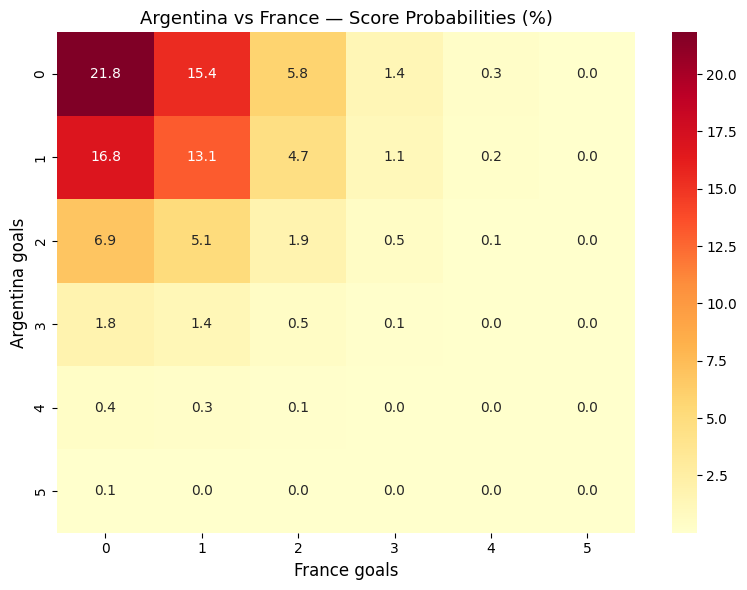


Spain vs Haiti (neutral venue)
Expected goals — Spain: 1.57, Haiti: 0.72
Spain win: 57.5% | Draw: 25.9% | Haiti win: 16.6%


In [26]:
fig, ax = plt.subplots(figsize=(8, 6))

matrix = result_probs['matrix']
sns.heatmap(
    matrix[:6, :6] * 100,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    ax=ax,
    xticklabels=range(6),
    yticklabels=range(6)
)

ax.set_xlabel(f'{away} goals', fontsize=12)
ax.set_ylabel(f'{home} goals', fontsize=12)
ax.set_title(f'{home} vs {away} — Score Probabilities (%)', fontsize=13)
plt.tight_layout()
plt.show()

# Also check a lopsided match for sanity
print("\nSpain vs Haiti (neutral venue)")
sp_result = match_probabilities('Spain', 'Haiti', fitted_params)
print(f"Expected goals — Spain: {sp_result['lambda_home']:.2f}, Haiti: {sp_result['lambda_away']:.2f}")
print(f"Spain win: {sp_result['home_win']:.1%} | Draw: {sp_result['draw']:.1%} | Haiti win: {sp_result['away_win']:.1%}")

In [27]:
# Check average expected goals across all WC team matchups
avg_goals = []
for team in teams_2026[:10]:  # sample 10 teams
    lh, la = get_lambda(fitted_params, team, 'France', n_teams, team_index, neutral=True)
    avg_goals.append((team, lh, la))

avg_df = pd.DataFrame(avg_goals, columns=['team', 'lambda_home', 'lambda_away'])
print(avg_df.round(3))
print(f"\nOverall avg lambda: {(avg_df['lambda_home'].mean() + avg_df['lambda_away'].mean())/2:.3f}")

        team  lambda_home  lambda_away
0  Argentina        0.802        0.737
1     Brazil        0.726        0.788
2    Uruguay        0.486        0.865
3   Colombia        0.612        0.958
4    Ecuador        0.362        0.928
5   Paraguay        0.193        1.153
6    Germany        0.847        1.033
7      Spain        1.015        0.761
8     France        0.834        0.834
9    England        0.796        0.672

Overall avg lambda: 0.770


In [28]:
# What is the actual average goals per team in our weighted dataset?
actual_avg_goals = (
    (df_clean['home_score'] * df_clean['weight']).sum() +
    (df_clean['away_score'] * df_clean['weight']).sum()
) / (2 * df_clean['weight'].sum())

print(f"Actual weighted avg goals per team: {actual_avg_goals:.3f}")
print(f"Model avg lambda:                   {0.770:.3f}")
print(f"Implied scaling factor:             {actual_avg_goals/0.770:.3f}")

Actual weighted avg goals per team: 1.365
Model avg lambda:                   0.770
Implied scaling factor:             1.772


In [29]:
# Check 1: what does the model predict vs actual for a few specific matches?
# Pick 5 recent high-weight matches
sample = df_clean.nlargest(10, 'weight')[['date', 'home_team', 'away_team', 
                                           'home_score', 'away_score', 'weight']]

print("Actual vs Model expected goals (recent high-weight matches):\n")
for _, row in sample.iterrows():
    ht, at = row['home_team'], row['away_team']
    # Skip if either team not in index
    if ht not in team_index or at not in team_index:
        continue
    lh, la = get_lambda(fitted_params, ht, at, n_teams, team_index, neutral=True)
    print(f"{ht} vs {at}")
    print(f"  Actual:   {int(row['home_score'])}-{int(row['away_score'])}")
    print(f"  Expected: {lh:.2f}-{la:.2f}")
    print()

# Check 2: is the constraint causing the issue?
# Print attack param distribution
print(f"\nAttack params — mean: {fitted_params[:n_teams].mean():.4f}, "
      f"std: {fitted_params[:n_teams].std():.4f}")
print(f"Defense params — mean: {fitted_params[n_teams:2*n_teams].mean():.4f}, "
      f"std: {fitted_params[n_teams:2*n_teams].std():.4f}")
print(f"Home advantage: {fitted_params[2*n_teams]:.4f}")
print(f"Rho: {fitted_params[2*n_teams+1]:.4f}")

# Check 3: what's the avg lambda for matches IN the training data?
sample_lambdas = []
for _, row in df_clean.nlargest(500, 'weight').iterrows():
    ht, at = row['home_team'], row['away_team']
    if ht not in team_index or at not in team_index:
        continue
    lh, la = get_lambda(fitted_params, ht, at, n_teams, team_index, neutral=bool(row['neutral']))
    sample_lambdas.extend([lh, la])

print(f"\nAvg lambda on top 500 weighted training matches: {np.mean(sample_lambdas):.3f}")

Actual vs Model expected goals (recent high-weight matches):

Morocco vs Senegal
  Actual:   3-0
  Expected: 0.55-0.53

Senegal vs Egypt
  Actual:   1-0
  Expected: 0.67-0.46

Egypt vs Ivory Coast
  Actual:   3-2
  Expected: 0.59-0.58

Algeria vs DR Congo
  Actual:   1-0
  Expected: 0.77-0.44


Attack params — mean: -0.0018, std: 0.3295
Defense params — mean: -0.3954, std: 0.1832
Home advantage: 0.6986
Rho: -0.0293

Avg lambda on top 500 weighted training matches: 0.902


In [30]:
# Reinitialize cleanly
params0 = initialize_params(n_teams)

# Anchor both attack AND defense means to 0
ref_idx = team_index['Switzerland']

def neg_log_likelihood_constrained(params):
    # Fix reference team attack to satisfy sum=0 constraint
    params[ref_idx] = -np.sum(np.delete(params[:n_teams], ref_idx))
    # Fix reference team defense to satisfy sum=0 constraint  
    params[n_teams + ref_idx] = -np.sum(np.delete(params[n_teams:2*n_teams], ref_idx))
    return neg_log_likelihood_fast(params)

print("Refitting with dual constraints...")
sys.stdout.flush()
start = time.time()

result = minimize(
    neg_log_likelihood_constrained,
    params0,
    method='L-BFGS-B',
    options={
        'maxiter': 2000,
        'maxfun': 50000,
        'ftol': 1e-9,
        'gtol': 1e-6
    }
)
elapsed = time.time() - start

fitted_params = result.x

attack_params  = fitted_params[:n_teams]
defense_params = fitted_params[n_teams:2*n_teams]

print(f"Converged: {result.success}")
print(f"Final NLL: {result.fun:.4f}")
print(f"Time:      {elapsed:.1f}s")
print(f"\nAttack  — mean: {attack_params.mean():.4f}, std: {attack_params.std():.4f}")
print(f"Defense — mean: {defense_params.mean():.4f}, std: {defense_params.std():.4f}")
print(f"Home advantage: {fitted_params[2*n_teams]:.4f}")
print(f"Rho:            {fitted_params[2*n_teams+1]:.4f}")

# Recheck Argentina vs France
lh, la = get_lambda(fitted_params, 'Argentina', 'France', n_teams, team_index, neutral=True)
print(f"\nArgentina vs France expected goals: {lh:.3f} - {la:.3f}")

# Recheck avg lambda
sample_lambdas = []
for _, row in df_clean.nlargest(500, 'weight').iterrows():
    ht, at = row['home_team'], row['away_team']
    if ht not in team_index or at not in team_index:
        continue
    lh, la = get_lambda(fitted_params, ht, at, n_teams, team_index, neutral=bool(row['neutral']))
    sample_lambdas.extend([lh, la])
print(f"Avg lambda on top 500 weighted matches: {np.mean(sample_lambdas):.3f}")

Refitting with dual constraints...
Converged: True
Final NLL: 4108.3442
Time:      42.8s

Attack  — mean: -0.0020, std: 0.3130
Defense — mean: -0.0003, std: 0.1673
Home advantage: 0.5093
Rho:            -0.0003

Argentina vs France expected goals: 1.015 - 1.151
Avg lambda on top 500 weighted matches: 1.199


In [31]:
# Rebuild params dataframe
params_df = pd.DataFrame({
    'team':    all_teams,
    'attack':  fitted_params[:n_teams],
    'defense': fitted_params[n_teams:2*n_teams],
}).set_index('team')

params_df['strength'] = params_df['attack'] - params_df['defense']
params_df = params_df.sort_values('strength', ascending=False)

print("Top 10:")
print(params_df.head(10).round(4))
print("\nBottom 10:")
print(params_df.tail(10).round(4))

# Recheck problem teams
print("\nProblem teams:")
for team in ['Ecuador', 'Paraguay', 'Uruguay']:
    lh, la = get_lambda(fitted_params, team, 'France', n_teams, team_index, neutral=True)
    print(f"  {team} vs France: {lh:.3f} - {la:.3f}")

Top 10:
             attack  defense  strength
team                                  
Spain        0.5063  -0.2562    0.7625
England      0.3377  -0.3354    0.6731
Portugal     0.4153  -0.1739    0.5892
Morocco      0.1798  -0.3977    0.5775
Japan        0.4475  -0.0812    0.5287
France       0.3193  -0.1916    0.5110
Belgium      0.4080  -0.0943    0.5023
Senegal      0.2072  -0.2916    0.4988
Netherlands  0.4040  -0.0635    0.4675
Algeria      0.3166  -0.0892    0.4058

Bottom 10:
                        attack  defense  strength
team                                             
South Africa           -0.3171   0.0611   -0.3782
Ghana                  -0.2654   0.1395   -0.4049
Qatar                  -0.1074   0.3181   -0.4255
Scotland               -0.2848   0.1421   -0.4269
Curaçao                -0.2150   0.2130   -0.4279
New Zealand            -0.0849   0.4340   -0.5189
Ecuador                -0.5611   0.0107   -0.5717
Cape Verde             -0.5993   0.0838   -0.6831
Bosnia and H

In [33]:
# Look at Paraguay's competitive record in detail
paraguay_competitive = df_clean[
    ((df_clean['home_team'] == 'Ecuador') | (df_clean['away_team'] == 'Ecuador')) &
    (df_clean['tournament'] != 'Friendly')
].copy()

# Compute result from Paraguay's perspective
def get_result(row, team):
    if row['home_team'] == team:
        g_for, g_against = row['home_score'], row['away_score']
    else:
        g_for, g_against = row['away_score'], row['home_score']
    if g_for > g_against: return 'W'
    elif g_for < g_against: return 'L'
    else: return 'D'

paraguay_competitive['result'] = paraguay_competitive.apply(
    lambda r: get_result(r, 'Ecuador'), axis=1
)
paraguay_competitive['goals_for'] = paraguay_competitive.apply(
    lambda r: r['home_score'] if r['home_team'] == 'Ecuador' else r['away_score'], axis=1
)
paraguay_competitive['goals_against'] = paraguay_competitive.apply(
    lambda r: r['away_score'] if r['home_team'] == 'Ecuador' else r['home_score'], axis=1
)

# Split by era
for year_from, year_to in [(1998,2010), (2010,2018), (2018,2023), (2023,2027)]:
    era = paraguay_competitive[
        (paraguay_competitive['date'].dt.year >= year_from) &
        (paraguay_competitive['date'].dt.year < year_to)
    ]
    if len(era) == 0:
        continue
    w = (era['result']=='W').sum()
    d = (era['result']=='D').sum()
    l = (era['result']=='L').sum()
    gf = era['goals_for'].mean()
    ga = era['goals_against'].mean()
    print(f"{year_from}-{year_to}: {w}W {d}D {l}L | avg goals {gf:.2f} for, {ga:.2f} against")

1998-2010: 28W 13D 34L | avg goals 1.21 for, 1.37 against
2010-2018: 16W 10D 21L | avg goals 1.32 for, 1.34 against
2018-2023: 8W 10D 11L | avg goals 1.31 for, 1.31 against
2023-2027: 9W 10D 3L | avg goals 0.86 for, 0.41 against


In [34]:
for year in [2015, 2016, 2017, 2018, 2019]:
    n = len(df_clean[df_clean['date'].dt.year >= year])
    wc_matches = len(df_clean[
        (df_clean['date'].dt.year >= year) & 
        (df_clean['tournament'] == 'FIFA World Cup')
    ])
    print(f"From {year}: {n} rows, {wc_matches} WC matches")

From 2015: 4819 rows, 124 WC matches
From 2016: 4364 rows, 124 WC matches
From 2017: 3961 rows, 124 WC matches
From 2018: 3539 rows, 124 WC matches
From 2019: 3161 rows, 63 WC matches


In [35]:
# Check match counts per WC team with 2018 cutoff
df_2018 = df_clean[df_clean['date'].dt.year >= 2018].copy()

counts = {}
for team in teams_2026:
    n = len(df_2018[
        (df_2018['home_team'] == team) | 
        (df_2018['away_team'] == team)
    ])
    counts[team] = n

counts_s = pd.Series(counts).sort_values()
print("Teams with fewest matches from 2018:")
print(counts_s.head(15))
print(f"\nTeams with fewer than 20 matches: {(counts_s < 20).sum()}")
print(f"Teams with fewer than 30 matches: {(counts_s < 30).sum()}")

Teams with fewest matches from 2018:
New Zealand               35
Curaçao                   53
Haiti                     61
Cape Verde                67
Ghana                     73
Australia                 76
Paraguay                  77
South Africa              78
Uzbekistan                78
Norway                    82
DR Congo                  82
Japan                     83
Bosnia and Herzegovina    83
Iran                      85
Canada                    85
dtype: int64

Teams with fewer than 20 matches: 0
Teams with fewer than 30 matches: 0


## Cambiar cutoff a 2018 para usar mejor la data reciente

In [36]:
# Apply 2018 cutoff
df_clean = df_clean[df_clean['date'].dt.year >= 2018].copy()

# Recompute static arrays
home_idx   = np.array([team_index.get(t, -1) for t in df_clean['home_team']])
away_idx   = np.array([team_index.get(t, -1) for t in df_clean['away_team']])
home_goals = df_clean['home_score'].values.astype(int)
away_goals = df_clean['away_score'].values.astype(int)
weights    = df_clean['weight'].values
neutral    = df_clean['neutral'].values.astype(bool)

# Reinitialize and refit
params0 = initialize_params(n_teams)

def neg_log_likelihood_constrained(params):
    params[ref_idx] = -np.sum(np.delete(params[:n_teams], ref_idx))
    params[n_teams + ref_idx] = -np.sum(np.delete(params[n_teams:2*n_teams], ref_idx))
    return neg_log_likelihood_fast(params)

print("Refitting with 2018 cutoff...")
sys.stdout.flush()
start = time.time()

result = minimize(
    neg_log_likelihood_constrained,
    params0,
    method='L-BFGS-B',
    options={'maxiter': 2000, 'maxfun': 50000, 'ftol': 1e-9, 'gtol': 1e-6}
)
elapsed = time.time() - start
fitted_params = result.x

print(f"Converged: {result.success}")
print(f"Final NLL: {result.fun:.4f}")
print(f"Time:      {elapsed:.1f}s")
print(f"\nAttack  — mean: {fitted_params[:n_teams].mean():.4f}")
print(f"Defense — mean: {fitted_params[n_teams:2*n_teams].mean():.4f}")
print(f"Home advantage: {fitted_params[2*n_teams]:.4f}")
print(f"Rho:            {fitted_params[2*n_teams+1]:.4f}")

# Rankings
params_df = pd.DataFrame({
    'team':    all_teams,
    'attack':  fitted_params[:n_teams],
    'defense': fitted_params[n_teams:2*n_teams],
}).set_index('team')
params_df['strength'] = params_df['attack'] - params_df['defense']
params_df = params_df.sort_values('strength', ascending=False)

print("\nTop 15:")
print(params_df.head(15).round(4))
print("\nBottom 10:")
print(params_df.tail(10).round(4))

# Recheck problem teams
print("\nProblem teams vs France:")
for team in ['Ecuador', 'Paraguay', 'Uruguay', 'Colombia']:
    lh, la = get_lambda(fitted_params, team, 'France', n_teams, team_index, neutral=True)
    print(f"  {team}: {lh:.3f} - {la:.3f}")

Refitting with 2018 cutoff...
Converged: True
Final NLL: 3405.7844
Time:      17.4s

Attack  — mean: -0.0021
Defense — mean: -0.0010
Home advantage: 0.5148
Rho:            0.0030

Top 15:
             attack  defense  strength
team                                  
Spain        0.5037  -0.2395    0.7432
England      0.3584  -0.3394    0.6978
Morocco      0.2232  -0.4280    0.6513
Portugal     0.4336  -0.1612    0.5947
Japan        0.4952  -0.0689    0.5641
Senegal      0.2467  -0.3165    0.5632
France       0.3643  -0.1757    0.5400
Belgium      0.4129  -0.1087    0.5216
Algeria      0.3497  -0.1425    0.4922
Netherlands  0.4137  -0.0519    0.4655
Argentina    0.2135  -0.1774    0.3908
Norway       0.2865   0.0057    0.2808
Germany      0.3105   0.0546    0.2559
Iran         0.2385   0.0292    0.2093
Ivory Coast  0.1180  -0.0853    0.2033

Bottom 10:
                        attack  defense  strength
team                                             
South Africa           -0.3012   0.07

In [37]:
def neg_log_likelihood_regularized(params):
    # Apply constraints
    params[ref_idx] = -np.sum(np.delete(params[:n_teams], ref_idx))
    params[n_teams + ref_idx] = -np.sum(np.delete(params[n_teams:2*n_teams], ref_idx))
    
    nll = neg_log_likelihood_fast(params)
    
    # L2 penalty — pulls extreme parameters toward zero
    # alpha controls strength: higher = more shrinkage toward average
    alpha = 0.02
    attack_penalty  = alpha * np.sum(params[:n_teams] ** 2)
    defense_penalty = alpha * np.sum(params[n_teams:2*n_teams] ** 2)
    
    return nll + attack_penalty + defense_penalty

# Refit with regularization
params0 = initialize_params(n_teams)

print("Refitting with L2 regularization...")
sys.stdout.flush()
start = time.time()

result = minimize(
    neg_log_likelihood_regularized,
    params0,
    method='L-BFGS-B',
    options={'maxiter': 2000, 'maxfun': 50000, 'ftol': 1e-9, 'gtol': 1e-6}
)
elapsed = time.time() - start
fitted_params = result.x

print(f"Converged: {result.success}")
print(f"Final NLL: {result.fun:.4f}")
print(f"Time:      {elapsed:.1f}s")

# Rankings
params_df = pd.DataFrame({
    'team':    all_teams,
    'attack':  fitted_params[:n_teams],
    'defense': fitted_params[n_teams:2*n_teams],
}).set_index('team')
params_df['strength'] = params_df['attack'] - params_df['defense']
params_df = params_df.sort_values('strength', ascending=False)

print("\nTop 15:")
print(params_df.head(15).round(4))
print("\nBottom 10:")
print(params_df.tail(10).round(4))

# Recheck problem teams
print("\nProblem teams vs France:")
for team in ['Ecuador', 'Paraguay', 'Uruguay', 'Colombia', 'Brazil']:
    lh, la = get_lambda(fitted_params, team, 'France', n_teams, team_index, neutral=True)
    print(f"  {team}: {lh:.3f} - {la:.3f}")

Refitting with L2 regularization...
Converged: True
Final NLL: 3405.9369
Time:      15.1s

Top 15:
             attack  defense  strength
team                                  
Spain        0.5031  -0.2391    0.7422
England      0.3579  -0.3389    0.6968
Morocco      0.2229  -0.4274    0.6503
Portugal     0.4331  -0.1610    0.5941
Japan        0.4947  -0.0688    0.5635
Senegal      0.2463  -0.3161    0.5625
France       0.3639  -0.1753    0.5392
Belgium      0.4124  -0.1085    0.5209
Algeria      0.3493  -0.1424    0.4917
Netherlands  0.4132  -0.0517    0.4649
Argentina    0.2132  -0.1773    0.3905
Norway       0.2860   0.0057    0.2804
Germany      0.3101   0.0546    0.2554
Iran         0.2380   0.0291    0.2089
Ivory Coast  0.1176  -0.0853    0.2029

Bottom 10:
                        attack  defense  strength
team                                             
South Africa           -0.3010   0.0708   -0.3718
Saudi Arabia           -0.3718   0.0253   -0.3971
New Zealand             0.

In [38]:
# Map each tournament+team combination to a confederation multiplier
# We'll apply this based on which teams are playing, not the tournament itself

confederation_map = {
    # CONMEBOL
    'Argentina': 1.2, 'Brazil': 1.2, 'Uruguay': 1.2, 'Colombia': 1.2,
    'Ecuador': 1.2, 'Paraguay': 1.2, 'Venezuela': 1.2, 'Chile': 1.2,
    'Peru': 1.2, 'Bolivia': 1.2,
    # UEFA
    'Spain': 1.15, 'England': 1.15, 'France': 1.15, 'Germany': 1.15,
    'Portugal': 1.15, 'Netherlands': 1.15, 'Belgium': 1.15, 'Italy': 1.15,
    'Croatia': 1.15, 'Austria': 1.15, 'Switzerland': 1.15, 'Norway': 1.15,
    'Scotland': 1.15, 'Sweden': 1.15, 'Turkey': 1.15, 'Denmark': 1.15,
    'Bosnia and Herzegovina': 1.15, 'Czech Republic': 1.15, 'Serbia': 1.15,
    'Ukraine': 1.15, 'Poland': 1.15, 'Hungary': 1.15,
    # CAF
    'Morocco': 1.05, 'Senegal': 1.05, 'Egypt': 1.05, 'Algeria': 1.05,
    'Nigeria': 1.05, 'Ivory Coast': 1.05, 'Ghana': 1.05, 'Tunisia': 1.05,
    'Cameroon': 1.05, 'Mali': 1.05, 'DR Congo': 1.05, 'Cape Verde': 1.05,
    'South Africa': 1.05,
    # AFC
    'Japan': 1.0, 'South Korea': 1.0, 'Iran': 1.0, 'Australia': 1.0,
    'Saudi Arabia': 1.0, 'Uzbekistan': 1.0, 'Jordan': 1.0, 'Iraq': 1.0,
    'Qatar': 1.0,
    # CONCACAF
    'United States': 1.05, 'Mexico': 1.05, 'Canada': 1.05, 'Panama': 1.05,
    'Costa Rica': 1.05, 'Honduras': 1.05, 'Jamaica': 1.05, 'Haiti': 1.05,
    'Curaçao': 1.05,
    # OFC
    'New Zealand': 0.95,
}

# Confederation weight = average of both teams' confederation multipliers
df_clean['conf_weight'] = df_clean.apply(
    lambda r: (confederation_map.get(r['home_team'], 1.0) + 
               confederation_map.get(r['away_team'], 1.0)) / 2,
    axis=1
)

# Apply to final weight
df_clean['weight'] = df_clean['competition_weight'] * df_clean['recency_weight'] * df_clean['conf_weight']

# Recompute static arrays
weights = df_clean['weight'].values

# Refit
params0 = initialize_params(n_teams)

print("Refitting with confederation weights...")
sys.stdout.flush()
start = time.time()

result = minimize(
    neg_log_likelihood_regularized,
    params0,
    method='L-BFGS-B',
    options={'maxiter': 2000, 'maxfun': 50000, 'ftol': 1e-9, 'gtol': 1e-6}
)
elapsed = time.time() - start
fitted_params = result.x

print(f"Converged: {result.success}")
print(f"Final NLL: {result.fun:.4f}")
print(f"Time:      {elapsed:.1f}s")

# Rankings
params_df = pd.DataFrame({
    'team':    all_teams,
    'attack':  fitted_params[:n_teams],
    'defense': fitted_params[n_teams:2*n_teams],
}).set_index('team')
params_df['strength'] = params_df['attack'] - params_df['defense']
params_df = params_df.sort_values('strength', ascending=False)

print("\nTop 15:")
print(params_df.head(15).round(4))
print("\nBottom 10:")
print(params_df.tail(10).round(4))

# Problem teams
print("\nProblem teams vs France:")
for team in ['Ecuador', 'Paraguay', 'Uruguay', 'Colombia', 'Brazil']:
    lh, la = get_lambda(fitted_params, team, 'France', n_teams, team_index, neutral=True)
    print(f"  {team}: {lh:.3f} - {la:.3f}")

Refitting with confederation weights...
Converged: True
Final NLL: 3640.9742
Time:      17.7s

Top 15:
             attack  defense  strength
team                                  
Spain        0.5112  -0.2532    0.7644
England      0.3579  -0.3471    0.7050
Morocco      0.2141  -0.4182    0.6323
Portugal     0.4446  -0.1753    0.6199
France       0.3763  -0.1903    0.5666
Senegal      0.2380  -0.3009    0.5388
Belgium      0.4138  -0.1180    0.5318
Japan        0.4755  -0.0454    0.5209
Argentina    0.2508  -0.2337    0.4845
Netherlands  0.4190  -0.0568    0.4758
Algeria      0.3401  -0.1318    0.4719
Norway       0.2886   0.0022    0.2864
Brazil       0.1203  -0.1646    0.2850
Germany      0.3194   0.0442    0.2752
Croatia      0.1626  -0.0500    0.2126

Bottom 10:
                        attack  defense  strength
team                                             
Iraq                   -0.3398   0.0496   -0.3894
South Africa           -0.3205   0.0809   -0.4014
Saudi Arabia          

In [39]:
# --- Piece 7: Expected Points Optimizer ---

def points_for_prediction(predicted_home, predicted_away, actual_home, actual_away):
    """
    Returns points scored given a prediction and actual result.
    Rules:
    - 3 pts: exact scoreline match
    - 2 pts: correct winner's goal count matches actual winner's goal count
    - 1 pt:  correct winner/draw predicted but wrong goal counts
    - 0 pts: wrong winner predicted
    """
    # Determine outcomes
    def outcome(h, a):
        if h > a: return 'home'
        elif a > h: return 'away'
        else: return 'draw'
    
    pred_outcome   = outcome(predicted_home, predicted_away)
    actual_outcome = outcome(actual_home, actual_away)
    
    # Wrong winner → 0 points
    if pred_outcome != actual_outcome:
        return 0
    
    # Exact score → 3 points
    if predicted_home == actual_home and predicted_away == actual_away:
        return 3
    
    # Draw case: correct draw but wrong goals → 1 point
    if actual_outcome == 'draw':
        return 1
    
    # Win case: check if winner's goal count matches
    if actual_outcome == 'home':
        if predicted_home == actual_home:
            return 2
        else:
            return 1
    else:  # away win
        if predicted_away == actual_away:
            return 2
        else:
            return 1


# Verify scoring rules with examples from the rules doc
test_cases = [
    (2, 1, 2, 1, 3),   # exact match → 3
    (2, 0, 2, 1, 2),   # winner goals match → 2
    (3, 1, 2, 1, 1),   # correct winner only → 1
    (2, 2, 1, 1, 1),   # correct draw wrong goals → 1
    (1, 2, 2, 1, 0),   # wrong winner → 0
    (0, 0, 1, 1, 1),   # correct draw wrong goals → 1
]

print("Scoring rule verification:")
print(f"{'Prediction':12} {'Actual':12} {'Expected':10} {'Got':5} {'Pass':5}")
print("-" * 50)
all_pass = True
for ph, pa, ah, aa, expected in test_cases:
    got = points_for_prediction(ph, pa, ah, aa)
    passed = got == expected
    all_pass = all_pass and passed
    print(f"{ph}-{pa:8}   {ah}-{aa:8}   {expected:8}   {got:3}   {'✓' if passed else '✗'}")

print(f"\nAll tests passed: {all_pass}")

Scoring rule verification:
Prediction   Actual       Expected   Got   Pass 
--------------------------------------------------
2-       1   2-       1          3     3   ✓
2-       0   2-       1          2     2   ✓
3-       1   2-       1          1     1   ✓
2-       2   1-       1          1     1   ✓
1-       2   2-       1          0     0   ✓
0-       0   1-       1          1     1   ✓

All tests passed: True


Argentina vs France
  Expected goals:  1.06 - 1.15
  Win probs:       ARG 33.2% | Draw 29.0% | FRA 37.8%
  Optimal pred:    0-1
  Expected points: 0.6295

Top 5 predictions by expected points:
  0-1: 0.6295 EP
  1-2: 0.6046 EP
  0-2: 0.6001 EP
  1-0: 0.5640 EP
  1-1: 0.5572 EP


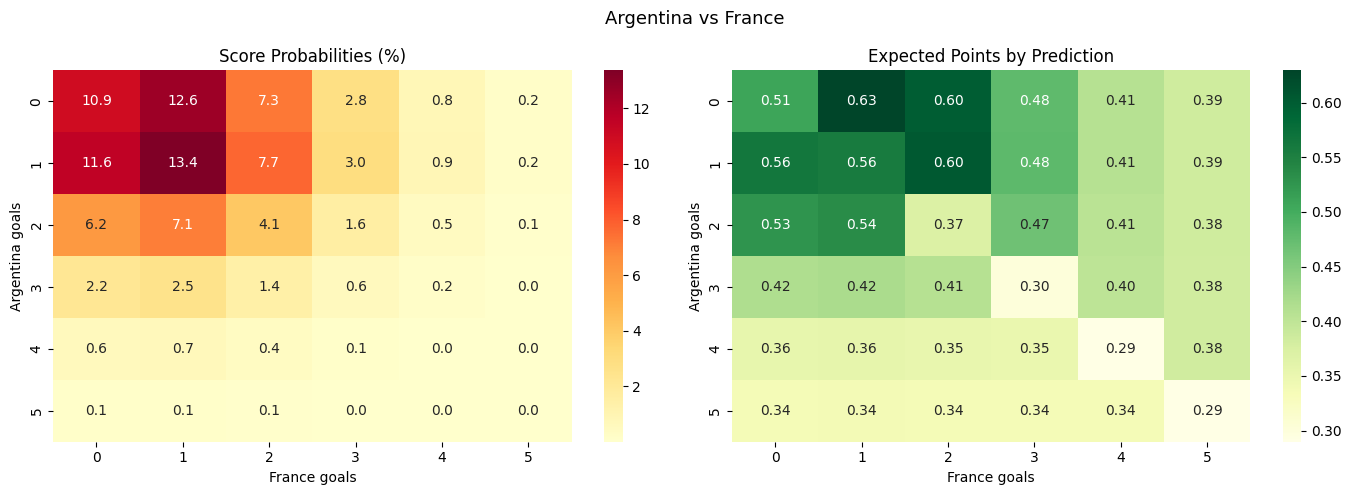

In [40]:
def expected_points(predicted_home, predicted_away, matrix, max_goals=8):
    """
    Computes expected points for a given prediction
    by summing points * probability over all possible actual scorelines
    """
    total = 0.0
    for actual_home in range(max_goals):
        for actual_away in range(max_goals):
            prob = matrix[actual_home, actual_away]
            pts  = points_for_prediction(
                predicted_home, predicted_away,
                actual_home, actual_away
            )
            total += prob * pts
    return total


def optimal_prediction(home_team, away_team, params, max_goals=8):
    """
    Finds the scoreline prediction that maximizes expected points.
    Returns the best prediction, its expected points, and full EP matrix.
    """
    matrix, lh, la = score_probability_matrix(
        home_team, away_team, params, max_goals=max_goals
    )
    
    best_pred    = (0, 0)
    best_ep      = -1
    ep_matrix    = np.zeros((max_goals, max_goals))
    
    for ph in range(max_goals):
        for pa in range(max_goals):
            ep = expected_points(ph, pa, matrix, max_goals)
            ep_matrix[ph, pa] = ep
            if ep > best_ep:
                best_ep   = ep
                best_pred = (ph, pa)
    
    # Match probabilities
    home_win = np.sum(np.tril(matrix, -1))
    draw     = np.sum(np.diag(matrix))
    away_win = np.sum(np.triu(matrix, 1))
    
    return {
        'home_team':    home_team,
        'away_team':    away_team,
        'prediction':   f"{best_pred[0]}-{best_pred[1]}",
        'pred_home':    best_pred[0],
        'pred_away':    best_pred[1],
        'expected_pts': best_ep,
        'home_win':     home_win,
        'draw':         draw,
        'away_win':     away_win,
        'lambda_home':  lh,
        'lambda_away':  la,
        'score_matrix': matrix,
        'ep_matrix':    ep_matrix,
    }


# Sanity check: Argentina vs France
pred = optimal_prediction('Argentina', 'France', fitted_params)

print(f"Argentina vs France")
print(f"  Expected goals:  {pred['lambda_home']:.2f} - {pred['lambda_away']:.2f}")
print(f"  Win probs:       ARG {pred['home_win']:.1%} | Draw {pred['draw']:.1%} | FRA {pred['away_win']:.1%}")
print(f"  Optimal pred:    {pred['prediction']}")
print(f"  Expected points: {pred['expected_pts']:.4f}")

# Show top 5 predictions by expected points
print(f"\nTop 5 predictions by expected points:")
scores = []
for ph in range(6):
    for pa in range(6):
        ep = pred['ep_matrix'][ph, pa]
        scores.append((f"{ph}-{pa}", ep))
scores.sort(key=lambda x: -x[1])
for scoreline, ep in scores[:5]:
    print(f"  {scoreline}: {ep:.4f} EP")

# Visualize EP matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pred['score_matrix'][:6,:6] * 100, annot=True, fmt='.1f',
            cmap='YlOrRd', ax=axes[0],
            xticklabels=range(6), yticklabels=range(6))
axes[0].set_title('Score Probabilities (%)')
axes[0].set_xlabel('France goals')
axes[0].set_ylabel('Argentina goals')

sns.heatmap(pred['ep_matrix'][:6,:6], annot=True, fmt='.2f',
            cmap='YlGn', ax=axes[1],
            xticklabels=range(6), yticklabels=range(6))
axes[1].set_title('Expected Points by Prediction')
axes[1].set_xlabel('France goals')
axes[1].set_ylabel('Argentina goals')

plt.suptitle('Argentina vs France', fontsize=13)
plt.tight_layout()
plt.show()

In [41]:
import pandas as pd

# Load 2022 data
games_2022  = pd.read_csv('historical_data/2022_games.csv',
                           header=None,
                           names=['phase', 'datetime', 'team1', 'team2'])

teams_2022  = pd.read_csv('historical_data/2022_teams.csv',
                           header=None,
                           names=['code', 'group'])

scores_2022 = pd.read_csv('historical_data/2022_scores.csv',
                           header=None,
                           names=['phase', 'team1', 'team2', 'score1', 'score2'])

preds_2022  = pd.read_csv('historical_data/2022_predictions.csv',
                           header=None,
                           names=['game_id', 'user_id', 'score1', 'score2'])

# Add game_id to games and scores (line number = game_id)
games_2022['game_id']  = range(1, len(games_2022) + 1)
scores_2022['game_id'] = range(1, len(scores_2022) + 1)

print(f"Games:       {len(games_2022)}")
print(f"Scores:      {len(scores_2022)}")
print(f"Predictions: {len(preds_2022)}")
print(f"Users:       {preds_2022['user_id'].nunique()}")
print(f"\nAll team codes in 2022:")
all_codes = sorted(set(teams_2022['code'].unique()))
print(all_codes)

Games:       64
Scores:      64
Predictions: 5091
Users:       85

All team codes in 2022:
['ARG', 'AUS', 'BEL', 'BRA', 'CAN', 'CMR', 'CRC', 'CRO', 'DEN', 'ECU', 'ENG', 'ESP', 'FRA', 'GER', 'GHA', 'IRN', 'JPN', 'KOR', 'KSA', 'MAR', 'MEX', 'NED', 'POL', 'POR', 'QAT', 'SEN', 'SRB', 'SUI', 'TUN', 'URU', 'USA', 'WAL']


In [42]:
# FIFA 3-letter code to full name mapping
# Must match EXACTLY the team names in df_clean / teams_2026
fifa_code_to_name = {
    # CONMEBOL
    'ARG': 'Argentina',
    'BRA': 'Brazil',
    'URU': 'Uruguay',
    'COL': 'Colombia',
    'ECU': 'Ecuador',
    'PAR': 'Paraguay',
    'VEN': 'Venezuela',
    'CHI': 'Chile',
    'PER': 'Peru',
    'BOL': 'Bolivia',
    # UEFA
    'ESP': 'Spain',
    'ENG': 'England',
    'FRA': 'France',
    'GER': 'Germany',
    'POR': 'Portugal',
    'NED': 'Netherlands',
    'BEL': 'Belgium',
    'CRO': 'Croatia',
    'AUT': 'Austria',
    'SUI': 'Switzerland',
    'NOR': 'Norway',
    'SCO': 'Scotland',
    'SWE': 'Sweden',
    'TUR': 'Turkey',
    'DEN': 'Denmark',
    'BIH': 'Bosnia and Herzegovina',
    'CZE': 'Czech Republic',
    'SRB': 'Serbia',
    'UKR': 'Ukraine',
    'POL': 'Poland',
    'HUN': 'Hungary',
    'ITA': 'Italy',
    'WAL': 'Wales',
    'GRE': 'Greece',
    'RUS': 'Russia',
    'SVK': 'Slovakia',
    'SVN': 'Slovenia',
    'ROU': 'Romania',
    # CAF
    'MAR': 'Morocco',
    'SEN': 'Senegal',
    'EGY': 'Egypt',
    'ALG': 'Algeria',
    'NGA': 'Nigeria',
    'CIV': 'Ivory Coast',
    'GHA': 'Ghana',
    'TUN': 'Tunisia',
    'CMR': 'Cameroon',
    'MLI': 'Mali',
    'COD': 'DR Congo',
    'CPV': 'Cape Verde',
    'RSA': 'South Africa',
    'ANG': 'Angola',
    'TOG': 'Togo',
    'BEN': 'Benin',
    # AFC
    'JPN': 'Japan',
    'KOR': 'South Korea',
    'IRN': 'Iran',
    'AUS': 'Australia',
    'KSA': 'Saudi Arabia',
    'UZB': 'Uzbekistan',
    'JOR': 'Jordan',
    'IRQ': 'Iraq',
    'QAT': 'Qatar',
    'CHN': 'China',
    'UAE': 'United Arab Emirates',
    # CONCACAF
    'USA': 'United States',
    'MEX': 'Mexico',
    'CAN': 'Canada',
    'PAN': 'Panama',
    'CRC': 'Costa Rica',
    'HON': 'Honduras',
    'JAM': 'Jamaica',
    'HAI': 'Haiti',
    'CUR': 'Curaçao',
    'TRI': 'Trinidad and Tobago',
    # OFC
    'NZL': 'New Zealand',
}

# Verify all 2022 codes are mapped
codes_2022 = ['ARG', 'AUS', 'BEL', 'BRA', 'CAN', 'CMR', 'CRC', 'CRO', 
              'DEN', 'ECU', 'ENG', 'ESP', 'FRA', 'GER', 'GHA', 'IRN', 
              'JPN', 'KOR', 'KSA', 'MAR', 'MEX', 'NED', 'POL', 'POR', 
              'QAT', 'SEN', 'SRB', 'SUI', 'TUN', 'URU', 'USA', 'WAL']

missing = [c for c in codes_2022 if c not in fifa_code_to_name]
print(f"Missing mappings: {missing}")

# Verify mapped names exist in our dataset
not_in_dataset = [c for c in codes_2022 
                  if fifa_code_to_name.get(c) not in 
                  set(df_clean['home_team'].unique()) | set(df_clean['away_team'].unique())]
print(f"Codes mapped but not in training data: {not_in_dataset}")
print(f"\nThese teams will be treated as 'average' in predictions:")
for c in not_in_dataset:
    print(f"  {c} → {fifa_code_to_name[c]}")

Missing mappings: []
Codes mapped but not in training data: []

These teams will be treated as 'average' in predictions:


In [8]:
import pandas as pd

pd.set_option("display.max_rows", None)

df = pd.read_csv("data/kaggle/results.csv")

df["date"] = pd.to_datetime(df["date"])

df.loc[df["date"].dt.year > 1986, "tournament"].value_counts()

tournament
Friendly                                                    11292
FIFA World Cup qualification                                 7255
UEFA Euro qualification                                      2194
African Cup of Nations qualification                         1935
AFC Asian Cup qualification                                   673
UEFA Nations League                                           658
African Cup of Nations                                        658
FIFA World Cup                                                624
CFU Caribbean Cup qualification                               540
CECAFA Cup                                                    465
CONCACAF Nations League                                       422
Gold Cup                                                      420
Copa América                                                  417
Island Games                                                  394
COSAFA Cup                                                    354

In [1]:
import pandas as pd

from src.loader import (
    DEFAULT_COMPETITION_WEIGHTS,
    load_pool_data,
    get_wc_teams,
)

KAGGLE_PATH = "data/kaggle/results.csv"
POOL_PATH = "data/pool"

# Use latest WC teams as proxy for modern relevance
pool = load_pool_data(POOL_PATH, 2022)
wc_teams = set(get_wc_teams(pool))

df = pd.read_csv(KAGGLE_PATH)

# Matches involving at least one 2022 World Cup team
df_wc = df[
    df["home_team"].isin(wc_teams)
    | df["away_team"].isin(wc_teams)
].copy()

excluded = df_wc[
    ~df_wc["tournament"].isin(DEFAULT_COMPETITION_WEIGHTS)
]

print(f"Excluded matches involving 2022 WC teams: {len(excluded)}")
print()

excluded_counts = (
    excluded["tournament"]
    .value_counts()
    .rename_axis("tournament")
    .reset_index(name="matches")
)

excluded_counts.head(50)

Excluded matches involving 2022 WC teams: 2689



,tournament,matches
0,British Home Championship,435
1,Merdeka Tournament,184
2,Asian Games,173
3,Nordic Championship,142
4,Confederations Cup,128
5,CONCACAF Championship,93
6,Korea Cup,89
7,Kirin Cup,71
8,Amílcar Cabral Cup,69
9,King's Cup,61


In [2]:
interesting = [
    "Asian Games",
    "Confederations Cup",
    "CONCACAF Championship",
    "Korea Cup",
    "Kirin Cup",
    "Olympic Games"
]

for tournament in interesting:

    subset = excluded[
        excluded["tournament"] == tournament
    ]

    teams = pd.concat([
        subset["home_team"],
        subset["away_team"]
    ])

    print()
    print("=" * 80)
    print(tournament)
    print("=" * 80)

    print(
        teams.value_counts().head(20)
    )


Asian Games
South Korea             61
Japan                   50
Iran                    48
Saudi Arabia            23
Qatar                   15
Kuwait                  14
India                   13
Malaysia                12
Thailand                12
Myanmar                 11
China PR                 9
Indonesia                8
Iraq                     7
North Korea              6
Bahrain                  5
Nepal                    4
Singapore                4
Bangladesh               4
United Arab Emirates     4
South Yemen              3
Name: count, dtype: int64

Confederations Cup
Brazil           33
Mexico           27
Australia        16
Japan            16
United States    15
Germany          13
Saudi Arabia     12
Cameroon         11
Argentina        10
France           10
Spain            10
Uruguay          10
New Zealand       8
Italy             7
Nigeria           5
Chile             5
Portugal          5
South Africa      4
Egypt             4
Turkey            4
N